#### Modeling

1. Logistic Regression으로 baseline을 잡아서 변수 하나하나가 선형적으로 어떤 방향으로 작용하는가를 먼저 확인
2. LightGBM으로 비선형 관계까지 잡아서 baseline 대비 ROC-AUC가 얼마나
   개선되는지 확인

- weekend_weekday_gap은 거의 0이라 신호로 보기 어려움
- gaming_ratio는 오히려 음의 상관(-0.19)
- social_gaming_hours와 screen_time_per_sleep은 예상보다 훨씬 강함(둘 다 0.48 근처)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb

pd.set_option("display.max_columns", None)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"

In [2]:
train = pd.read_csv("../data/train_fe.csv")
test = pd.read_csv("../data/test_fe.csv")

In [3]:
target = "addicted_label"
cat_raw_cols = ["gender", "stress_level", "academic_work_impact"]
drop_cols = ["id", target] + cat_raw_cols
features = [c for c in train.columns if c not in drop_cols]

X = train[features]
y = train[target]

len(features)

30

#### Baseline - Logistic Regression

선형모델 돌리는 이유 : 복잡한 모델이 잡아내는 관계가 실제로 비선형적인 것인지 나중에 비교할 기준을 만들기 위함

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_oof = np.zeros(len(X))
lr_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr_scaled, y_tr)

    pred = model.predict_proba(X_val_scaled)[:, 1]
    lr_oof[val_idx] = pred

    fold_auc = roc_auc_score(y_val, pred)
    lr_scores.append(fold_auc)
    print(f"fold {fold} auc: {fold_auc:.5f}")

print(f"LR 평균 auc: {np.mean(lr_scores):.5f}")

fold 0 auc: 0.91565
fold 1 auc: 0.91598
fold 2 auc: 0.91716
fold 3 auc: 0.91722
fold 4 auc: 0.91686
LR 평균 auc: 0.91657


#### LightGBM

gaming_ratio의 음의 상관 같은 건 선형 모델(LR)의 계수 부호로도 확인. 
LightGBM에서는 계수가 아니라 분기(split) 형태로 반영되기 때문에 두 모델의 해석 방식이 다르다는 점을 염두에 두고 결과를 비교

In [5]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "seed": 42,
    "verbosity": -1,
}

lgb_oof = np.zeros(len(X))
lgb_scores = []
lgb_models = []

In [6]:
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    train_set = lgb.Dataset(X_tr, y_tr)
    valid_set = lgb.Dataset(X_val, y_val)

    model = lgb.train(
        lgb_params, train_set, valid_sets=[valid_set],
        num_boost_round=2000,
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )

    pred = model.predict(X_val, num_iteration=model.best_iteration)
    lgb_oof[val_idx] = pred

    fold_auc = roc_auc_score(y_val, pred)
    lgb_scores.append(fold_auc)
    lgb_models.append(model)
    print(f"fold {fold} auc: {fold_auc:.5f}")

print(f"LightGBM 평균 auc: {np.mean(lgb_scores):.5f}")

fold 0 auc: 0.96215
fold 1 auc: 0.96275
fold 2 auc: 0.96332
fold 3 auc: 0.96381
fold 4 auc: 0.96269
LightGBM 평균 auc: 0.96294


#### 모델 비교 - ROC Curve
fold별 숫자 비교만으로는 어느 구간에서 더 잘 구분하는지 알 수 없음.OOF 예측 전체로 ROC Curve를 그려서 두 모델의 곡선 자체를 비교

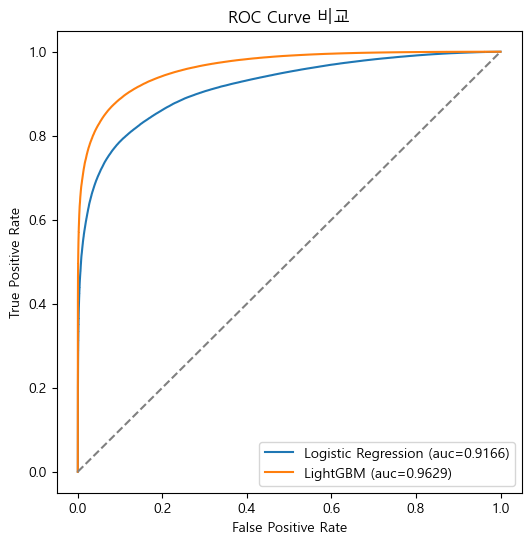

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y, lr_oof)
fpr_lgb, tpr_lgb, _ = roc_curve(y, lgb_oof)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (auc={np.mean(lr_scores):.4f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (auc={np.mean(lgb_scores):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve 비교")
plt.legend()
plt.show()

#### Fold별 성능 비교

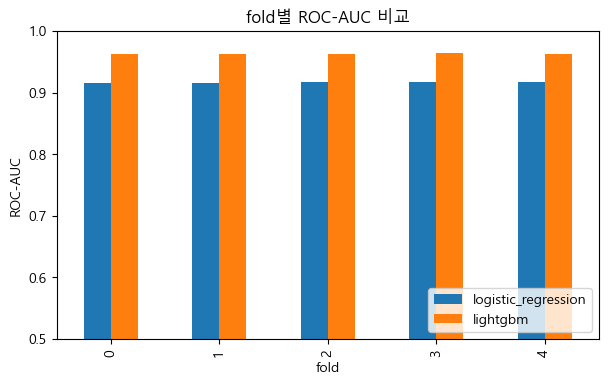

In [8]:
fold_compare = pd.DataFrame({
    "fold": range(len(lr_scores)),
    "logistic_regression": lr_scores,
    "lightgbm": lgb_scores,
})

fold_compare.set_index("fold").plot(kind="bar", figsize=(7, 4))
plt.title("fold별 ROC-AUC 비교")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.legend(loc="lower right")
plt.show()

fold 간 편차가 크면 데이터 분할 / 특정 구간의 이상치 의심

#### Feature Importance 

- 강할 것으로 기대: daily_screen_time_hours, weekend_screen_time,
  social_media_hours, social_gaming_hours, screen_time_per_sleep
- 방향은 확인이 필요하지만 신호는 있을 것: gaming_ratio (음의 방향으로
  작동할 가능성)
- 약할 것으로 기대: weekend_weekday_gap, notifications_per_day,
  app_opens_per_day, *_missing indicator

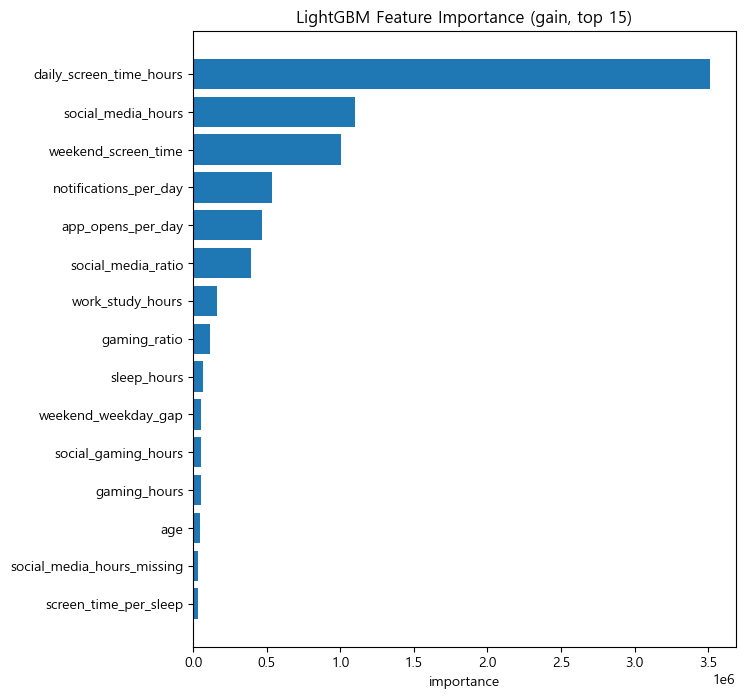

,daily_screen_time_hours,screen_time_per_sleep,social_gaming_hours
daily_screen_time_hours,1.000000,0.860198,0.616214
screen_time_per_sleep,0.860198,1.000000,0.527375
social_gaming_hours,0.616214,0.527375,1.000000


In [9]:
importance = pd.DataFrame({
    "feature": features,
    "importance": np.mean([m.feature_importance(importance_type="gain") for m in lgb_models], axis=0),
}).sort_values("importance", ascending=False)

plt.figure(figsize=(7, 8))
plt.barh(importance["feature"][:15][::-1], importance["importance"][:15][::-1])
plt.title("LightGBM Feature Importance (gain, top 15)")
plt.xlabel("importance")
plt.show()

# screen_time_per_sleep, social_gaming_hours가 하위권으로 나온 이유 확인
# daily_screen_time_hours와의 상관관계가 각각 0.86 / 0.62로 높음
# → 예측력이 없어서가 아니라 daily_screen_time_hours가 이미 같은 정보를 가져갔기 때문
train[["daily_screen_time_hours", "screen_time_per_sleep", "social_gaming_hours"]].corr()

#### OOF 저장 (Ensemble/SHAP 단계에서 재사용)

In [10]:
oof_df = pd.DataFrame({
    "id": train["id"],
    "addicted_label": y,
    "lr_oof": lr_oof,
    "lgb_oof": lgb_oof,
})
oof_df.to_csv("../output/oof_predictions.csv", index=False)